In [35]:
import ast
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)

In [36]:
# ── Paths ────────────────────────────────────────────────
CSV_PATH = "..\\Datasets\\rtde_data.csv"
SAVE_DIR = "..\\Models\\TCN"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────────────
SAMPLE_RATE      = 100
GAP_THRESHOLD    = 0.015
VELOCITY_EPSILON = 0.001

# ── MLP AE ───────────────────────────────────────────────
LATENT_DIM = 16
DROPOUT    = 0.2

# ── Training ─────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 50
LEARNING_RATE = 1e-3

# ── Anomaly ──────────────────────────────────────────────
THRESHOLD_PERCENTILE = 99.9

# ── Split ────────────────────────────────────────────────
VAL_SIZE  = 0.10
TEST_SIZE = 0.10

In [37]:
df = pd.read_csv(CSV_PATH)

print(f"Shape    : {df.shape}")
print(f"Duration : {len(df) / SAMPLE_RATE:.1f} seconds")
print(f"Columns  : {list(df.columns)}")
df.head(3)

Shape    : (33486, 14)
Duration : 334.9 seconds
Columns  : ['timestamp', 'target_q', 'target_qd', 'target_qdd', 'target_current', 'target_moment', 'actual_q', 'actual_qd', 'actual_current', 'joint_temperatures', 'joint_mode', 'target_TCP_pose', 'actual_TCP_pose', 'robot_mode']


,timestamp,target_q,target_qd,target_qdd,target_current,target_moment,actual_q,actual_qd,actual_current,joint_temperatures,joint_mode,target_TCP_pose,actual_TCP_pose,robot_mode
0,265686.834,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.2126688723411795e-16, -0.7857670787312422, ...","[1.3855484745821294e-15, -8.988702786535187, -...","[-0.20763665834535772, -1.9363509617247523, 1....","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.23777902126312256, -0.9878473281860352, -1....","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632254996455616, -0.057974038383734536, ...",7
1,265686.842,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.180065856588544e-16, -0.7857197440113755, -...","[1.3482975318283752e-15, -8.98816130580905, -2...","[-0.2076485792743128, -1.9363271198668421, 1.9...","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.2560155987739563, -1.0181230306625366, -1.8...","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632962076385607, -0.05798160780578084, 0...",7
2,265686.850,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.017134512430945e-16, -0.785726478581895, -2...","[1.1621384899760469e-15, -8.988238345245335, -...","[-0.20761281648744756, -1.9363509617247523, 1....","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.2293904721736908, -1.0122623443603516, -1.8...","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632629669394063, -0.057981910944731596, ...",7


In [38]:
keep_cols = [
    'actual_current',      
    'target_current',      
    'joint_temperatures',  
    'target_moment',       
]

existing_keep = [c for c in keep_cols if c in df.columns]
df = df[existing_keep]

print(f"Kept columns : {list(df.columns)}")
print(f"Shape        : {df.shape}")

Kept columns : ['actual_current', 'target_current', 'joint_temperatures', 'target_moment']
Shape        : (33486, 4)


In [39]:
for col in df.columns:
    sample = df[col].iloc[0]
    if not isinstance(sample, str):
        print(f"[SKIP] '{col}' already parsed")
        continue

    parsed = df[col].apply(ast.literal_eval)
    n = len(parsed.iloc[0])
    expanded = pd.DataFrame(
        parsed.tolist(),
        columns=[f"{col}_{i}" for i in range(n)],
        index=df.index
    )
    df = pd.concat([df.drop(columns=[col]), expanded], axis=1)
    print(f"Expanded '{col}' → {n} columns")

print(f"\nShape after expansion: {df.shape}")
df.head(3)

Expanded 'actual_current' → 6 columns
Expanded 'target_current' → 6 columns
Expanded 'joint_temperatures' → 6 columns
Expanded 'target_moment' → 6 columns

Shape after expansion: (33486, 24)


,actual_current_0,actual_current_1,actual_current_2,actual_current_3,actual_current_4,actual_current_5,target_current_0,target_current_1,target_current_2,target_current_3,...,joint_temperatures_2,joint_temperatures_3,joint_temperatures_4,joint_temperatures_5,target_moment_0,target_moment_1,target_moment_2,target_moment_3,target_moment_4,target_moment_5
0,0.237779,-0.987847,-1.872177,-0.520921,0.050121,-0.303221,1.212669e-16,-0.785767,-2.191135,-0.378155,...,26.75,31.25,34.125,35.1875,1.385548e-15,-8.988703,-25.263701,-2.958802,0.011053,0.0
1,0.256016,-1.018123,-1.891300,-0.522808,0.067461,-0.294840,1.180066e-16,-0.785720,-2.191132,-0.378152,...,26.75,31.25,34.125,35.1875,1.348298e-15,-8.988161,-25.263667,-2.958778,0.011079,0.0
2,0.229390,-1.012262,-1.897665,-0.525495,0.053996,-0.295797,1.017135e-16,-0.785726,-2.191138,-0.378161,...,26.75,31.25,34.125,35.1875,1.162138e-15,-8.988238,-25.263744,-2.958850,0.011028,0.0


In [40]:
for i in range(6):
    df[f'track_err_I_{i}'] = df[f'actual_current_{i}'] - df[f'target_current_{i}']

target_cols = [f'target_current_{i}' for i in range(6)]
df.drop(columns=target_cols, inplace=True)

print(f"Shape : {df.shape}")
print(f"Features : {list(df.columns)}")

Shape : (33486, 24)
Features : ['actual_current_0', 'actual_current_1', 'actual_current_2', 'actual_current_3', 'actual_current_4', 'actual_current_5', 'joint_temperatures_0', 'joint_temperatures_1', 'joint_temperatures_2', 'joint_temperatures_3', 'joint_temperatures_4', 'joint_temperatures_5', 'target_moment_0', 'target_moment_1', 'target_moment_2', 'target_moment_3', 'target_moment_4', 'target_moment_5', 'track_err_I_0', 'track_err_I_1', 'track_err_I_2', 'track_err_I_3', 'track_err_I_4', 'track_err_I_5']


In [41]:
from sklearn.model_selection import train_test_split

X_temp, X_test = train_test_split(df, test_size=TEST_SIZE, shuffle=False)
X_train, X_val = train_test_split(X_temp, test_size=VAL_SIZE/(1-TEST_SIZE), shuffle=False)

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")
print(f"Test  : {len(X_test):,} rows")

Train : 26,788 rows
Val   : 3,349 rows
Test  : 3,349 rows


In [42]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))

['..\\Models\\TCN\\scaler.pkl']

In [43]:
N_ANOMALIES = 10   

rng = np.random.default_rng(42)
anomaly_indices = rng.choice(len(X_test), size=N_ANOMALIES, replace=False)

X_test_anomaly = X_test.copy()
X_test_anomaly[anomaly_indices] += np.random.normal(0, 3, (N_ANOMALIES, X_test.shape[1]))

# Labels: 0 = normal, 1 = anomaly
y_test = np.zeros(len(X_test), dtype=int)
y_test[anomaly_indices] = 1

print(f"X_test       : {X_test_anomaly.shape}")
print(f"Normal rows  : {(y_test == 0).sum():,}")
print(f"Anomaly rows : {(y_test == 1).sum():,}")
print(f"Anomaly idx  : {sorted(anomaly_indices)}")

X_test       : (3349, 24)
Normal rows  : 3,339
Anomaly rows : 10
Anomaly idx  : [np.int64(287), np.int64(298), np.int64(315), np.int64(674), np.int64(1448), np.int64(1467), np.int64(2187), np.int64(2334), np.int64(2585), np.int64(2872)]


In [44]:
def AE(input_dim, latent_dim, dropout):
    # Encoder
    inputs  = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    encoded = layers.Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = layers.Dense(64, activation='relu')(encoded)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)

    model = Model(inputs, decoded, name='MLP_Autoencoder')
    return model


INPUT_DIM = X_train.shape[1]   # 24 features

model = AE(INPUT_DIM, LATENT_DIM, DROPOUT)
model.summary()

Model: "MLP_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,000 (97.66 KB)

 Trainable params: 25,000 (97.66 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'best_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

In [46]:
history = model.fit(
    X_train, X_train,          
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, model_checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/50
418/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6599
Epoch 1: val_loss improved from None to 0.25687, saving model to ..\Models\TCN\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4844 - val_loss: 0.2569 - learning_rate: 0.0010
Epoch 2/50
398/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3041
Epoch 2: val_loss improved from 0.25687 to 0.21321, saving model to ..\Models\TCN\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2893 - val_loss: 0.2132 - learning_rate: 0.0010
Epoch 3/50
402/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2574
Epoch 3: val_loss improved from 0.21321 to 0.17787, saving model to ..\Models\TCN\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2509 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 4/50
398/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2354
Epoch 4: val_loss improved from 0.17787 to 0.16965, saving model to ..\Models\TCN\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step -

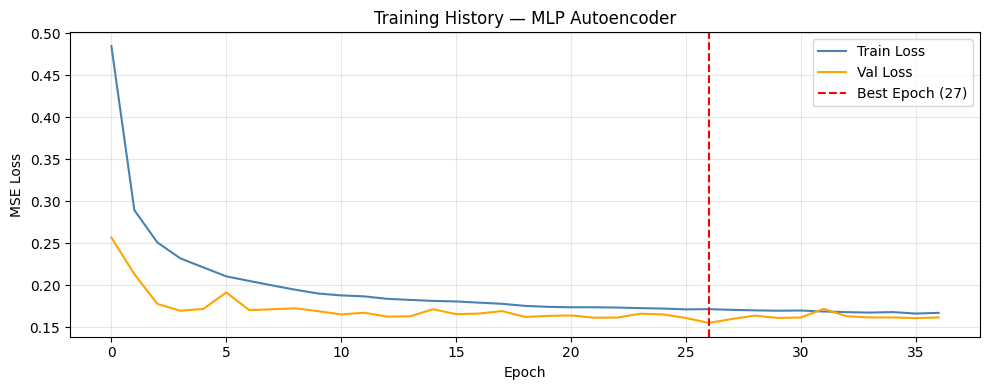

Best epoch     : 27
Best val_loss  : 0.1552


In [47]:
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')

best_epoch = np.argmin(history.history['val_loss'])
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch + 1})')

plt.title('Training History — MLP Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best epoch     : {best_epoch + 1}")
print(f"Best val_loss  : {history.history['val_loss'][best_epoch]:.4f}")

In [48]:
train_preds = model.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - train_preds), axis=1)

threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

# ── Save ─────────────────────────────────────────────────
joblib.dump(threshold, os.path.join(SAVE_DIR, 'threshold.pkl'))

print(f"Train error — mean : {train_errors.mean():.4f}")
print(f"Train error — std  : {train_errors.std():.4f}")
print(f"Train error — max  : {train_errors.max():.4f}")
print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile) : {threshold:.4f}")
print("Threshold saved ✓")

Train error — mean : 0.0935
Train error — std  : 0.0561
Train error — max  : 1.0417
Threshold (99.9th percentile) : 0.5377
Threshold saved ✓


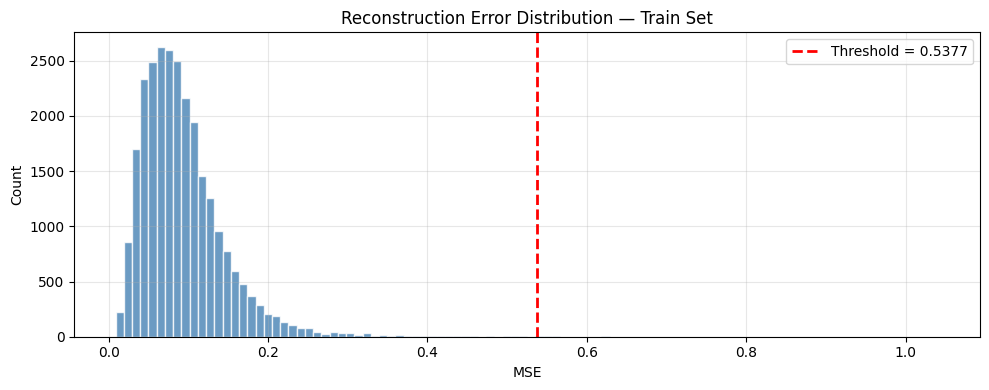

In [49]:
# ── Plot distribution ────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.title('Reconstruction Error Distribution — Train Set')
plt.xlabel('MSE')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# ── حسب الـ reconstruction error على الـ test ────────────
test_preds  = model.predict(X_test_anomaly, verbose=0)
test_errors = np.mean(np.square(X_test_anomaly - test_preds), axis=1)

# ── Predict: فوق الـ threshold = anomaly ─────────────────
y_pred = (test_errors > threshold).astype(int)

print(f"Threshold         : {threshold:.4f}")
print(f"Normal detected   : {(y_pred == 0).sum():,}")
print(f"Anomaly detected  : {(y_pred == 1).sum():,}")

Threshold         : 0.5377
Normal detected   : 3,225
Anomaly detected  : 124



Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      3339
     Anomaly       0.08      1.00      0.15        10

    accuracy                           0.97      3349
   macro avg       0.54      0.98      0.57      3349
weighted avg       1.00      0.97      0.98      3349



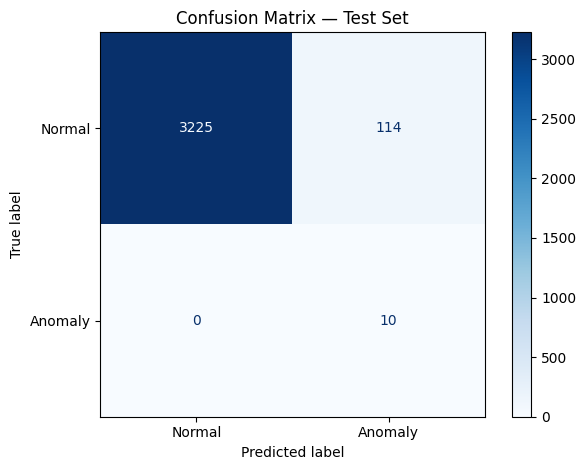

In [51]:
# ── Evaluation Metrics ───────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()